# 4.4 - EDA and Preparing Data for Machine Learning Models

Practice exercise using **Starbucks_reviews.csv**.

## 1. Load the data and import libraries

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../../../Lab/Starbucks_reviews.csv")
df.head()


,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         850 non-null    object 
 1   location     850 non-null    object 
 2   Date         850 non-null    object 
 3   Rating       705 non-null    float64
 4   Review       850 non-null    object 
 5   Image_Links  850 non-null    object 
dtypes: float64(1), object(5)
memory usage: 40.0+ KB


## 2. Visualize missing data

First, check how many missing values appear in each feature.

In [10]:
df.isnull().sum()

name             0
location         0
Date             0
Rating         145
Review           0
Image_Links      0
dtype: int64

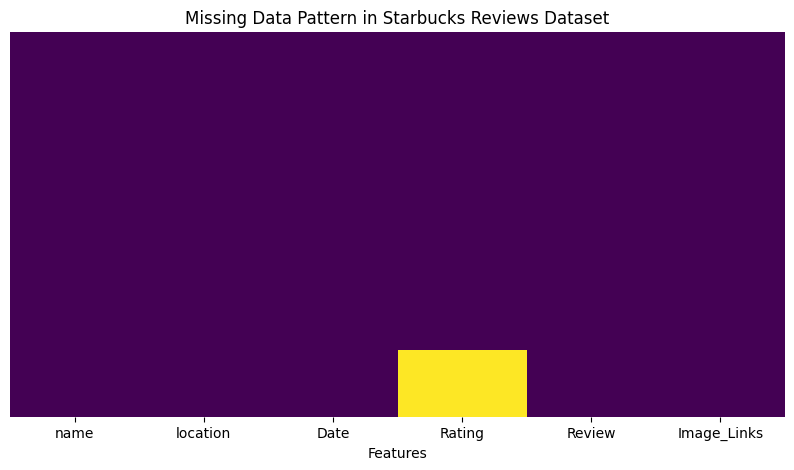

In [11]:

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Pattern in Starbucks Reviews Dataset")
plt.xlabel("Features")
plt.show()


### Missing-data conclusion
The main feature with missing data is **Rating**. The other columns in this dataset appear complete. This means any machine learning workflow that uses ratings directly would need to decide how to handle those missing values before modeling.

## 3. Display the feature `Rating`

The dataset uses the column name **Rating** (capital R).

In [12]:
df["Rating"].describe()

count    705.000000
mean       1.870922
std        1.397672
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: Rating, dtype: float64

In [13]:
df["Rating"].value_counts(dropna=False).sort_index()

Rating
1.0    451
2.0     99
3.0     33
4.0     39
5.0     83
NaN    145
Name: count, dtype: int64

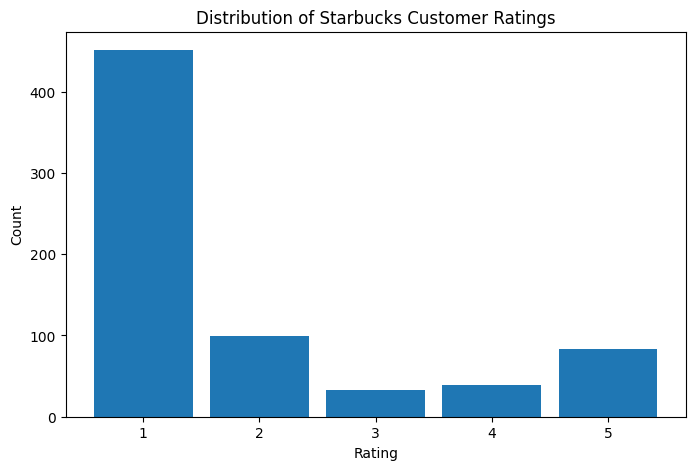

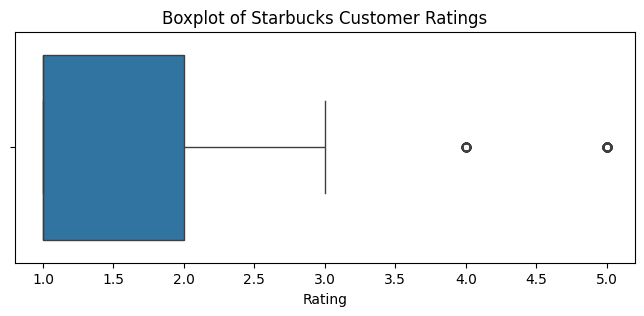

In [14]:

plt.figure(figsize=(8, 5))
df["Rating"].dropna().plot(kind="hist", bins=np.arange(0.5, 6.5, 1), rwidth=0.85)
plt.title("Distribution of Starbucks Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["Rating"].dropna())
plt.title("Boxplot of Starbucks Customer Ratings")
plt.xlabel("Rating")
plt.show()


### Rating conclusion
The ratings are heavily concentrated at the low end, especially **1-star reviews**. The median rating is **1**, and the mean is also low, which suggests this dataset contains many dissatisfied customer experiences. Higher ratings are much less common than low ratings.

## 4. Visualize the text of the reviews

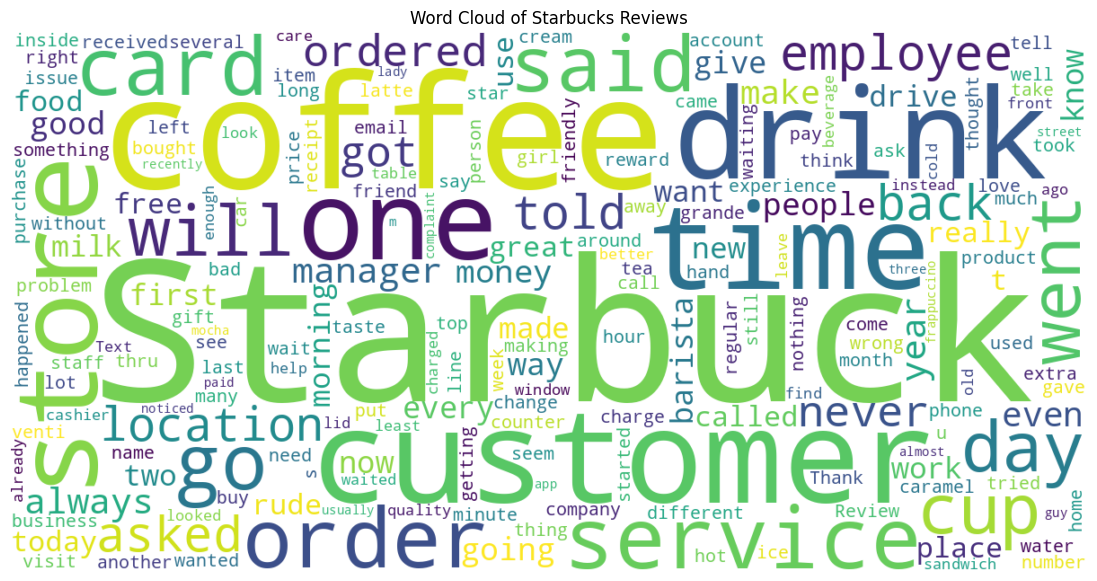

In [15]:

text = " ".join(df["Review"].dropna().astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Starbucks Reviews")
plt.show()


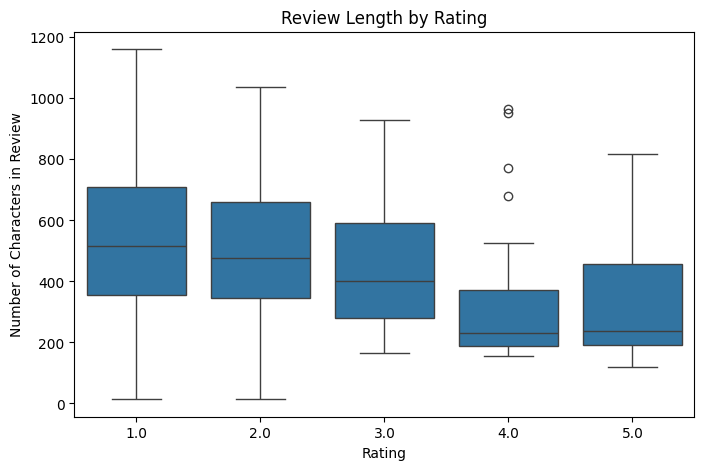

In [16]:

df["review_length"] = df["Review"].fillna("").str.len()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df.dropna(subset=["Rating"]), x="Rating", y="review_length")
plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Characters in Review")
plt.show()


### Text-data conclusion
The word cloud shows that terms such as **Starbucks, coffee, customer, service, store, drink,** and **order** appear often, which suggests customers mainly talk about service experiences, orders, drinks, and store interactions. The review-length boxplot also suggests that lower-rated reviews tend to be longer on average, which makes sense because unhappy customers often write more detailed complaints.

## Final takeaway

This Starbucks review dataset appears useful for text analysis and sentiment-related modeling. Before building a machine learning model, an analyst would likely need to:

- handle missing values in **Rating**
- clean and preprocess the **Review** text
- possibly extract features such as review length, sentiment, or keyword frequency
- examine whether the ratings are too imbalanced for certain supervised learning tasks